# Implementing a Neural Network with Gradient Descent Optimization

# Importing


In [409]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD
import matplotlib.pyplot as plt
import seaborn as sb
from PIL import Image

# Showing the Neural Network


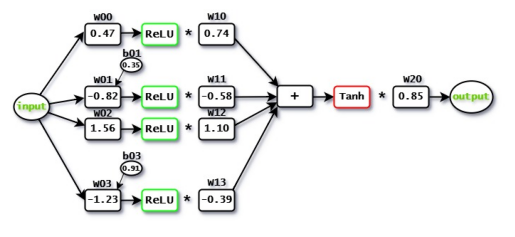

In [410]:
Neural_img = Image.open("Neural_Network.jpg")


plt.imshow(Neural_img)
plt.axis("off")
plt.show()

# Initalize the Network

In [411]:
class first_NN(nn.Module):
    
    
    def __init__(self ):
        super().__init__()
        
        self.w00 = nn.Parameter(torch.tensor(0.47), requires_grad=False)

        self.w01 = nn.Parameter(torch.tensor(-0.82), requires_grad=False)
        self.b01 = nn.Parameter(torch.tensor(0.35), requires_grad=False)

        self.w02 = nn.Parameter(torch.tensor(1.56), requires_grad=False)

        self.w03 = nn.Parameter(torch.tensor(-1.23), requires_grad=False)
        self.b03 = nn.Parameter(torch.tensor(0.91), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(0.74), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(-0.58), requires_grad=False)
        self.w12 = nn.Parameter(torch.tensor(1.10), requires_grad=False)
        self.w13 = nn.Parameter(torch.tensor(-0.39), requires_grad=False)

        self.w20 = nn.Parameter(torch.tensor(0.85), requires_grad=False)


        
    def forward(self,input):
        input_from_layer_00=input*self.w00
        output_fron_layer_00=F.relu(input_from_layer_00)
        output_fron_layer_00=self.w10*output_fron_layer_00

        input_from_layer_01=input*self.w01+self.b01
        output_fron_layer_01=F.relu(input_from_layer_01)
        output_fron_layer_01=self.w11*output_fron_layer_01
        
        input_from_layer_02=input*self.w02
        output_fron_layer_02=F.relu(input_from_layer_02)
        output_fron_layer_02=self.w12*output_fron_layer_02
        
        input_from_layer_03=input*self.w03+self.b03
        output_fron_layer_03=F.relu(input_from_layer_03)
        output_fron_layer_03=output_fron_layer_03*self.w13
        
        output_from_first_layer=output_fron_layer_00+output_fron_layer_01+output_fron_layer_02+output_fron_layer_03
        
        output_from_first_layer=F.tanh(output_from_first_layer)
        
        output=output_from_first_layer*self.w20
        return output

In [412]:
Actual_Model=first_NN()

In [413]:
inputs=torch.linspace(start=1,end=2.5,steps=60)
inputs



tensor([1.0000, 1.0254, 1.0508, 1.0763, 1.1017, 1.1271, 1.1525, 1.1780, 1.2034,
        1.2288, 1.2542, 1.2797, 1.3051, 1.3305, 1.3559, 1.3814, 1.4068, 1.4322,
        1.4576, 1.4831, 1.5085, 1.5339, 1.5593, 1.5847, 1.6102, 1.6356, 1.6610,
        1.6864, 1.7119, 1.7373, 1.7627, 1.7881, 1.8136, 1.8390, 1.8644, 1.8898,
        1.9153, 1.9407, 1.9661, 1.9915, 2.0169, 2.0424, 2.0678, 2.0932, 2.1186,
        2.1441, 2.1695, 2.1949, 2.2203, 2.2458, 2.2712, 2.2966, 2.3220, 2.3475,
        2.3729, 2.3983, 2.4237, 2.4492, 2.4746, 2.5000])

In [414]:
outputs=Actual_Model(inputs)

outputs

tensor([0.8230, 0.8257, 0.8281, 0.8302, 0.8322, 0.8339, 0.8355, 0.8370, 0.8382,
        0.8394, 0.8405, 0.8414, 0.8423, 0.8430, 0.8437, 0.8443, 0.8449, 0.8454,
        0.8459, 0.8463, 0.8466, 0.8470, 0.8473, 0.8476, 0.8478, 0.8480, 0.8482,
        0.8484, 0.8485, 0.8487, 0.8488, 0.8489, 0.8490, 0.8491, 0.8492, 0.8493,
        0.8494, 0.8494, 0.8495, 0.8495, 0.8496, 0.8496, 0.8497, 0.8497, 0.8497,
        0.8498, 0.8498, 0.8498, 0.8498, 0.8498, 0.8499, 0.8499, 0.8499, 0.8499,
        0.8499, 0.8499, 0.8499, 0.8499, 0.8499, 0.8499])

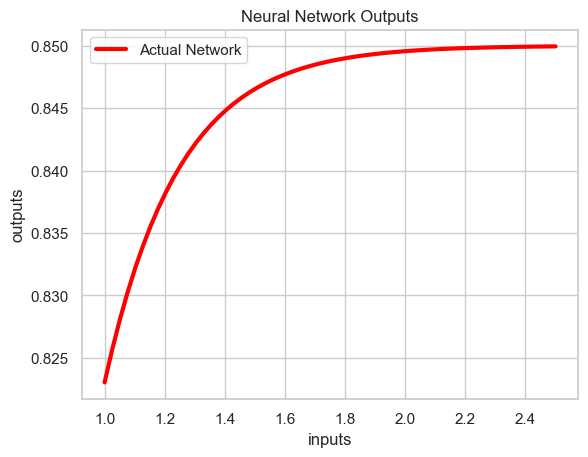

In [415]:
sb.set_theme(style='whitegrid')

sb.lineplot(
    x=inputs,
    y=outputs,
    color='red',
    linewidth=3,
    label='Actual Network'
)
plt.xlabel('inputs')
plt.ylabel('outputs')
plt.title('Neural Network Outputs')

plt.show()

In [416]:
class first_non_trained_NN(nn.Module):
    
    
    def __init__(self ):
        super().__init__()
                        
        self.w00 = nn.Parameter(torch.tensor(0.39), requires_grad=True)

        self.w01 = nn.Parameter(torch.tensor(-0.73), requires_grad=True)
        self.b01 = nn.Parameter(torch.tensor(0.28), requires_grad=True)

        self.w02 = nn.Parameter(torch.tensor(1.41), requires_grad=True)

        self.w03 = nn.Parameter(torch.tensor(-1.08), requires_grad=True)
        self.b03 = nn.Parameter(torch.tensor(0.82), requires_grad=True)

        self.w10 = nn.Parameter(torch.tensor(0.66), requires_grad=True)
        self.w11 = nn.Parameter(torch.tensor(-0.49), requires_grad=True)

        self.w12 = nn.Parameter(torch.tensor(0.97), requires_grad=True)
        self.w13 = nn.Parameter(torch.tensor(-0.31), requires_grad=True)

        self.w20 = nn.Parameter(torch.tensor(0.76), requires_grad=True)



        
    def forward(self,input):
        input_from_layer_00=input*self.w00
        output_fron_layer_00=F.relu(input_from_layer_00)
        output_fron_layer_00=self.w10*output_fron_layer_00

        input_from_layer_01=input*self.w01+self.b01
        output_fron_layer_01=F.relu(input_from_layer_01)
        output_fron_layer_01=self.w11*output_fron_layer_01
        
        input_from_layer_02=input*self.w02
        output_fron_layer_02=F.relu(input_from_layer_02)
        output_fron_layer_02=self.w12*output_fron_layer_02
        
        input_from_layer_03=input*self.w03+self.b03
        output_fron_layer_03=F.relu(input_from_layer_03)
        output_fron_layer_03=output_fron_layer_03*self.w13
        
        output_from_first_layer=output_fron_layer_00+output_fron_layer_01+output_fron_layer_02+output_fron_layer_03
        
        output_from_first_layer=F.tanh(output_from_first_layer)
        
        output=output_from_first_layer*self.w20
        
        return output

In [417]:
non_trained_model=first_non_trained_NN()

In [418]:
outputs_of_non_trained=non_trained_model(inputs)

outputs_of_non_trained

tensor([0.7033, 0.7076, 0.7116, 0.7154, 0.7188, 0.7220, 0.7249, 0.7277, 0.7302,
        0.7325, 0.7346, 0.7366, 0.7384, 0.7401, 0.7417, 0.7431, 0.7445, 0.7457,
        0.7468, 0.7478, 0.7488, 0.7497, 0.7505, 0.7512, 0.7519, 0.7526, 0.7532,
        0.7537, 0.7542, 0.7547, 0.7551, 0.7555, 0.7558, 0.7562, 0.7565, 0.7567,
        0.7570, 0.7572, 0.7575, 0.7577, 0.7578, 0.7580, 0.7582, 0.7583, 0.7584,
        0.7586, 0.7587, 0.7588, 0.7589, 0.7590, 0.7591, 0.7591, 0.7592, 0.7593,
        0.7593, 0.7594, 0.7594, 0.7595, 0.7595, 0.7596],
       grad_fn=<MulBackward0>)

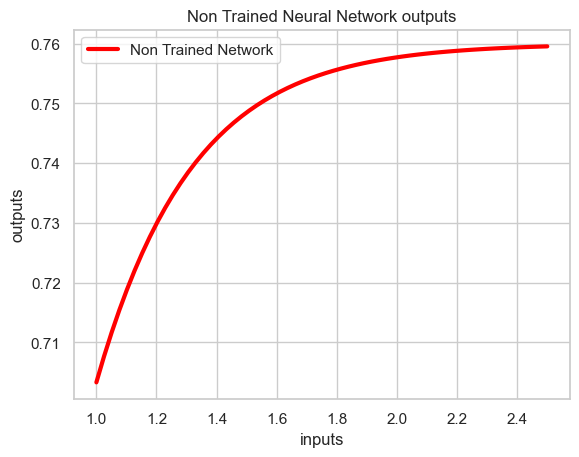

In [419]:
sb.set_theme(style='whitegrid')

sb.lineplot(
    x=inputs,
    y=outputs_of_non_trained.detach(),
    color='red',
    linewidth=3,
    label='Non Trained Network'
)

plt.xlabel('inputs')
plt.ylabel('outputs')
plt.title('Non Trained Neural Network outputs')

plt.show()

# Training the Neural Network Using Stochastic Gradient Descent

In [420]:
before_training_outputs = non_trained_model(inputs).detach()

In [421]:
optimizer=SGD(non_trained_model.parameters(),lr=0.01)

loss = nn.MSELoss()


In [422]:

for epoch in range(828):
    
    total_loss=0
    
    for i in range (len(inputs)):
        input_i=inputs[i]
        outputs_i=outputs[i]
        predected_output_i=non_trained_model(input_i)
        
        loss_value=loss(predected_output_i,outputs_i) # line to see what is the differance then makes backpropagation using SGD
        
        loss_value.backward()
        total_loss += loss_value.item()
        
    print(f"epoch : {epoch} , loss : {total_loss}")
    optimizer.step()
    optimizer.zero_grad() # Optimizer using acumalative steps if we not using the zerograd the opitmizer will calculate the previos operations
    

epoch : 0 , loss : 0.5744773577898741
epoch : 1 , loss : 0.021382977604062603
epoch : 2 , loss : 0.0059334491913922704
epoch : 3 , loss : 0.005444080786194405
epoch : 4 , loss : 0.005380037364847823
epoch : 5 , loss : 0.0053287535938295605
epoch : 6 , loss : 0.0052785232473837596
epoch : 7 , loss : 0.005229014205298199
epoch : 8 , loss : 0.005180195100365381
epoch : 9 , loss : 0.005132047867959955
epoch : 10 , loss : 0.005084573319265928
epoch : 11 , loss : 0.005037756585835496
epoch : 12 , loss : 0.0049915681176742055
epoch : 13 , loss : 0.0049460098124143315
epoch : 14 , loss : 0.004901080457628382
epoch : 15 , loss : 0.004856748566609781
epoch : 16 , loss : 0.004813009850508365
epoch : 17 , loss : 0.004769858212213762
epoch : 18 , loss : 0.004727277124658258
epoch : 19 , loss : 0.004685259132173769
epoch : 20 , loss : 0.004643792625884657
epoch : 21 , loss : 0.004602871207598724
epoch : 22 , loss : 0.004562473986709392
epoch : 23 , loss : 0.0045226085442351405
epoch : 24 , loss : 0.

In [423]:
trained_outputs = non_trained_model(inputs).detach()

# Final Comparison : Actual VS Non-Trained VS Trained Neural Network


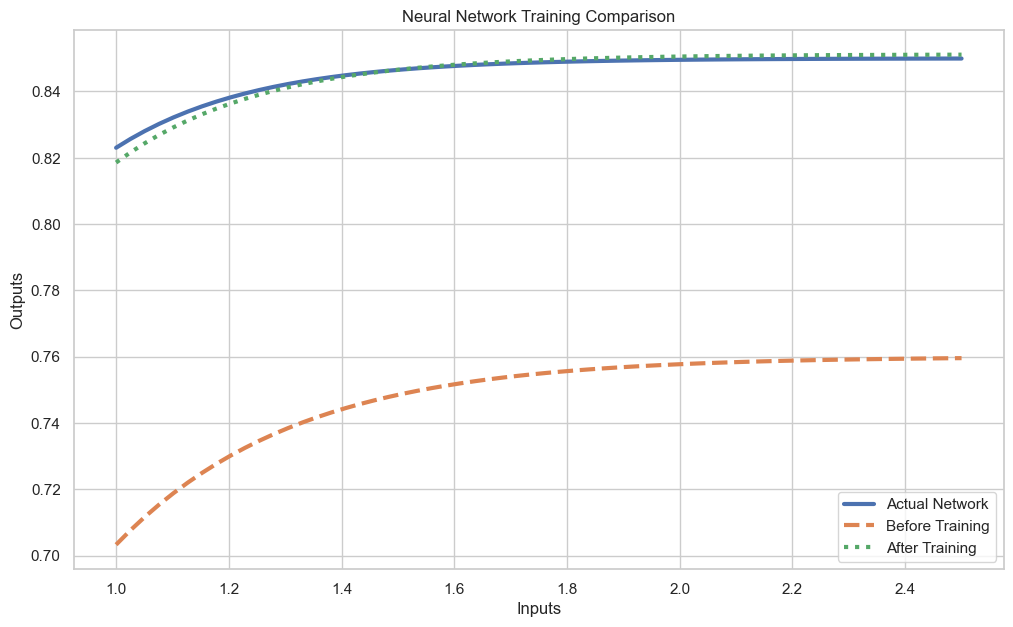

In [424]:
import matplotlib.pyplot as plt
import seaborn as sb

sb.set_theme(style="whitegrid")

plt.figure(figsize=(12,7))


# Actual Network
sb.lineplot(
    x=inputs.numpy(),
    y=outputs.detach().numpy(),
    linewidth=3,
    label="Actual Network"
)

# Before Training
sb.lineplot(
    x=inputs.numpy(),
    y=before_training_outputs.numpy(),
    linewidth=3,
    linestyle="--",
    label="Before Training"
)

# After Training
sb.lineplot(
    x=inputs.numpy(),
    y=trained_outputs.numpy(),
    linewidth=3,
    linestyle=":",
    label="After Training"
)

plt.xlabel("Inputs")
plt.ylabel("Outputs")

plt.title("Neural Network Training Comparison")

plt.legend()

plt.show()